In [ ]:
!pip install -q xgboost shap streamlit joblib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.1/10.1 MB 65.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 93.9 MB/s eta 0:00:00


## 1. Environment and Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    precision_recall_curve
)

from xgboost import XGBClassifier
import shap
import joblib

print("Libraries imported successfully!")

Libraries imported successfully!


## 2. Load Dataset

In [ ]:
df = pd.read_csv("Telco-Customer-Churn.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (7043, 21)


In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [ ]:
# dataset info
print("Columns:")
for column in df.columns:
    print(column)

print("\nDataset Information:")
df.info()

Columns:
customerID
gender
SeniorCitizen
Partner
Dependents
tenure
PhoneService
MultipleLines
InternetService
OnlineSecurity
OnlineBackup
DeviceProtection
TechSupport
StreamingTV
StreamingMovies
Contract
PaperlessBilling
PaymentMethod
MonthlyCharges
TotalCharges
Churn

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null  

In [ ]:
# Check missing values
missing_values = df.isnull().sum()

print("Missing values:")
print(missing_values[missing_values > 0])

# Check blank values in object columns
blank_values = (df.select_dtypes(include="object") == "").sum()

print("\nBlank values:")
print(blank_values[blank_values > 0])

Missing values:
Series([], dtype: int64)

Blank values:
Series([], dtype: int64)


In [ ]:
#check total charge
print("TotalCharges data type:")
print(df["TotalCharges"].dtype)

TotalCharges data type:
object


In [ ]:
# target distribution
print("Churn Count:")
print(df["Churn"].value_counts())

print("\nChurn Percentage:")
print(
    df["Churn"].value_counts(normalize=True) * 100
)

Churn Count:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Percentage:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


In [ ]:
# create clean dataset
df_clean = df.copy()

print("Copy created successfully!")
print("Original shape:", df_clean.shape)

Copy created successfully!
Original shape: (7043, 21)


In [ ]:
# check duplicates
print("Duplicate rows:", df_clean.duplicated().sum())
print("Duplicate customer IDs:", df_clean["customerID"].duplicated().sum())

Duplicate rows: 0
Duplicate customer IDs: 0


In [ ]:
#convert total charge
df_clean["TotalCharges"] = pd.to_numeric(
    df_clean["TotalCharges"],
    errors="coerce"
)

print("TotalCharges dtype:", df_clean["TotalCharges"].dtype)
print(
    "Missing TotalCharges:",
    df_clean["TotalCharges"].isnull().sum()
)

TotalCharges dtype: float64
Missing TotalCharges: 11


In [ ]:
# handle missing values
df_clean = df_clean.dropna(
    subset=["TotalCharges"]
)

print("Shape after removing missing values:")
print(df_clean.shape)

Shape after removing missing values:
(7032, 21)


In [ ]:
#remove customer ID
df_clean = df_clean.drop(
    "customerID",
    axis=1
)

print("Shape after removing customerID:")
print(df_clean.shape)

Shape after removing customerID:
(7032, 20)


In [ ]:
#verify clean data
print(df_clean.info())

print("\nTotal missing values:")
print(df_clean.isnull().sum().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7032 non-null   object 
 1   SeniorCitizen     7032 non-null   int64  
 2   Partner           7032 non-null   object 
 3   Dependents        7032 non-null   object 
 4   tenure            7032 non-null   int64  
 5   PhoneService      7032 non-null   object 
 6   MultipleLines     7032 non-null   object 
 7   InternetService   7032 non-null   object 
 8   OnlineSecurity    7032 non-null   object 
 9   OnlineBackup      7032 non-null   object 
 10  DeviceProtection  7032 non-null   object 
 11  TechSupport       7032 non-null   object 
 12  StreamingTV       7032 non-null   object 
 13  StreamingMovies   7032 non-null   object 
 14  Contract          7032 non-null   object 
 15  PaperlessBilling  7032 non-null   object 
 16  PaymentMethod     7032 non-null   object 
 17  

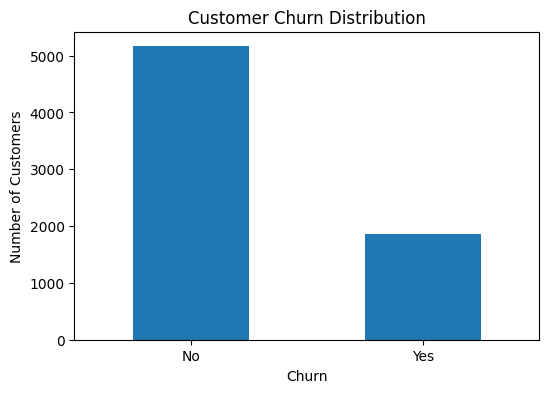

Churn
No     73.421502
Yes    26.578498
Name: proportion, dtype: float64


In [ ]:
## 3. Exploratory Data Analysis

### Churn Distribution
plt.figure(figsize=(6, 4))

df_clean["Churn"].value_counts().plot(
    kind="bar"
)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)

plt.show()

churn_percentage = (
    df_clean["Churn"]
    .value_counts(normalize=True) * 100
)

print(churn_percentage)

In [ ]:
# contract vs churn
contract_churn = pd.crosstab(
    df_clean["Contract"],
    df_clean["Churn"],
    normalize="index"
) * 100

print(contract_churn)

Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.722826  11.277174
Two year        97.151335   2.848665


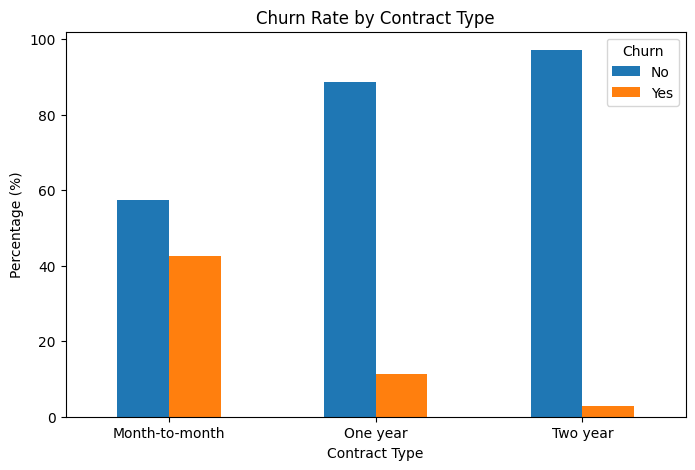

In [ ]:
#contract visualization
contract_churn.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

<Figure size 800x500 with 0 Axes>

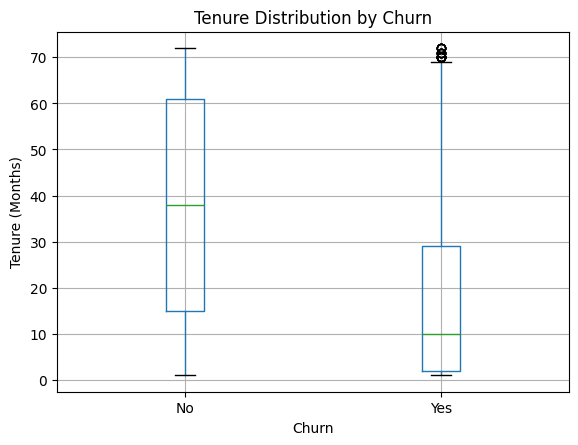

In [ ]:
# tenure vs churn
plt.figure(figsize=(8, 5))

df_clean.boxplot(
    column="tenure",
    by="Churn"
)

plt.title("Tenure Distribution by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Tenure (Months)")

plt.show()

<Figure size 800x500 with 0 Axes>

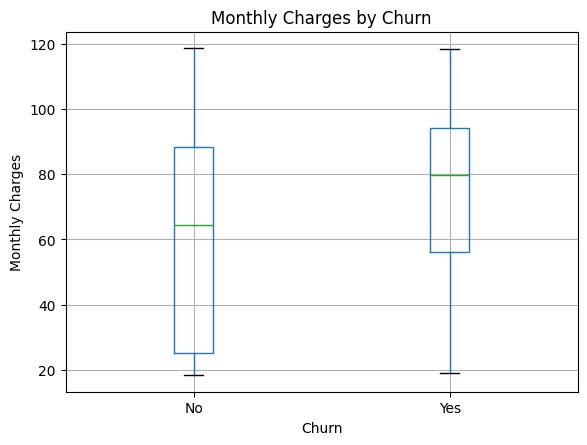

In [ ]:
#monthly charges vs churn
plt.figure(figsize=(8, 5))

df_clean.boxplot(
    column="MonthlyCharges",
    by="Churn"
)

plt.title("Monthly Charges by Churn")
plt.suptitle("")
plt.xlabel("Churn")
plt.ylabel("Monthly Charges")

plt.show()

In [ ]:
#payment method vs churn
payment_churn = pd.crosstab(
    df_clean["PaymentMethod"],
    df_clean["Churn"],
    normalize="index"
) * 100

print(payment_churn)

Churn                             No        Yes
PaymentMethod                                  
Bank transfer (automatic)  83.268482  16.731518
Credit card (automatic)    84.746877  15.253123
Electronic check           54.714588  45.285412
Mailed check               80.798005  19.201995


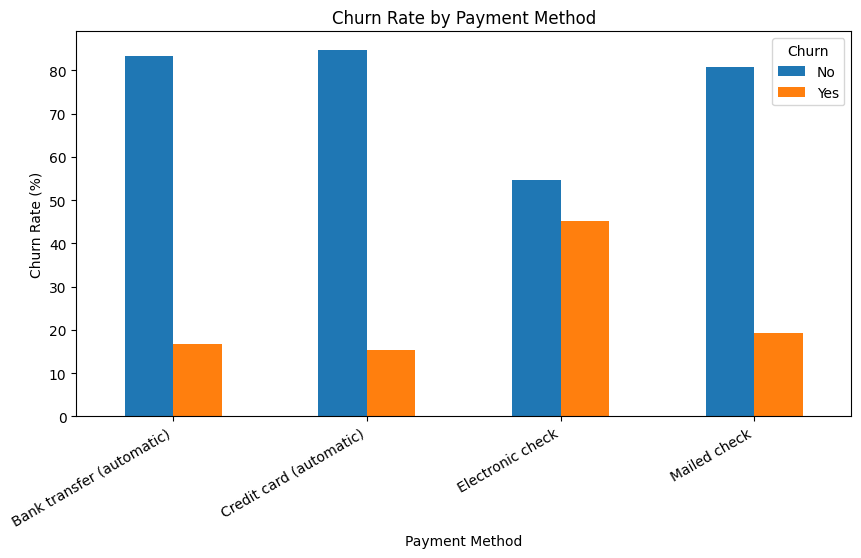

In [ ]:
# payment visualization
payment_churn.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(
    rotation=30,
    ha="right"
)
plt.legend(title="Churn")

plt.show()

In [ ]:
# Internet service vs churn
internet_churn = pd.crosstab(
    df_clean["InternetService"],
    df_clean["Churn"],
    normalize="index"
) * 100

print(internet_churn)

Churn                   No        Yes
InternetService                      
DSL              81.001656  18.998344
Fiber optic      58.107235  41.892765
No               92.565789   7.434211


<Axes: xlabel='InternetService'>

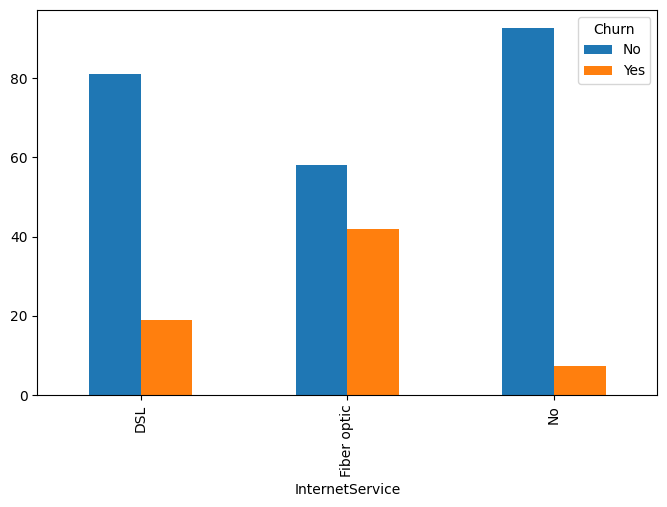

In [ ]:
    internet_churn.plot(
        kind="bar",
        figsize=(8, 5)
    )

In [ ]:
# Tenure groups
df_clean["tenure_group"] = pd.cut(
    df_clean["tenure"],
    bins=[0, 12, 24, 48, 60, 72],
    labels=[
        "0-12 months",
        "13-24 months",
        "25-48 months",
        "49-60 months",
        "61-72 months"
    ],
    include_lowest=True
)

tenure_churn = pd.crosstab(
    df_clean["tenure_group"],
    df_clean["Churn"],
    normalize="index"
) * 100

print(tenure_churn)

Churn                No        Yes
tenure_group                      
0-12 months   52.321839  47.678161
13-24 months  71.289062  28.710938
25-48 months  79.611041  20.388959
49-60 months  85.576923  14.423077
61-72 months  93.390192   6.609808


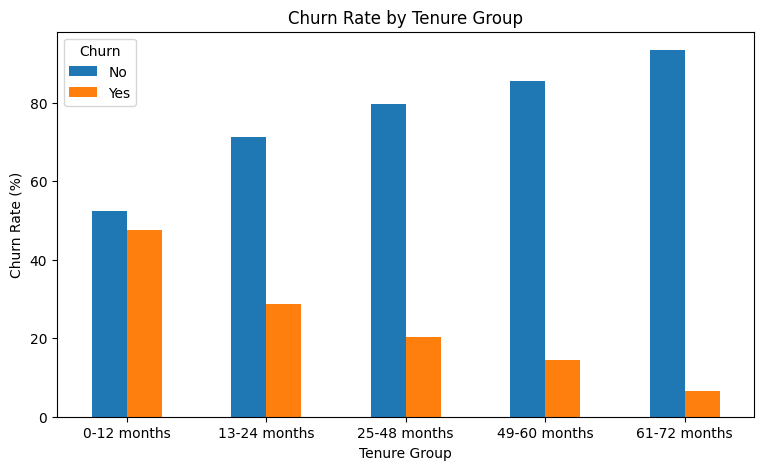

In [ ]:
# Tenure group visualization
tenure_churn.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

In [ ]:
# senior citizen vs churn
senior_churn = pd.crosstab(
    df_clean["SeniorCitizen"],
    df_clean["Churn"],
    normalize="index"
) * 100

print(senior_churn)

Churn                 No        Yes
SeniorCitizen                      
0              76.349745  23.650255
1              58.318739  41.681261


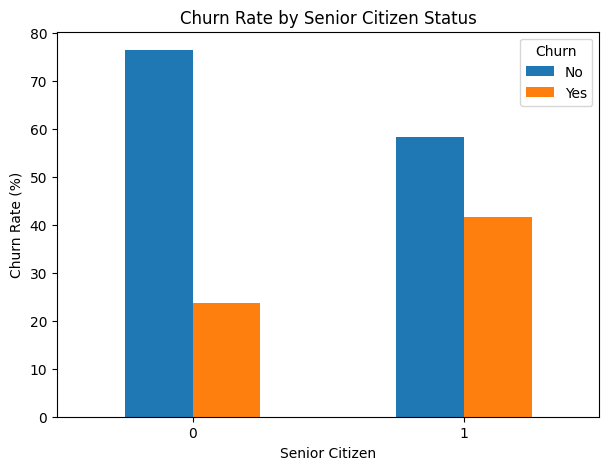

In [ ]:
# senior citizen visualization
senior_churn.plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Churn Rate by Senior Citizen Status")
plt.xlabel("Senior Citizen")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

In [ ]:
# Business statistics
print("Average Monthly Charges:")
print(
    df_clean.groupby("Churn")["MonthlyCharges"].mean()
)

print("\nAverage Tenure:")
print(
    df_clean.groupby("Churn")["tenure"].mean()
)

print("\nAverage Total Charges:")
print(
    df_clean.groupby("Churn")["TotalCharges"].mean()
)

Average Monthly Charges:
Churn
No     61.307408
Yes    74.441332
Name: MonthlyCharges, dtype: float64

Average Tenure:
Churn
No     37.650010
Yes    17.979133
Name: tenure, dtype: float64

Average Total Charges:
Churn
No     2555.344141
Yes    1531.796094
Name: TotalCharges, dtype: float64


In [ ]:
# Feature engineering: total services
service_columns = [
    "PhoneService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies"
]

df_clean["total_services"] = (df_clean[service_columns] == "Yes").sum(axis=1)

print(df_clean["total_services"].describe())

count    7032.000000
mean        2.941411
std         1.843695
min         0.000000
25%         1.000000
50%         3.000000
75%         4.000000
max         7.000000
Name: total_services, dtype: float64


In [ ]:
# High value customer
print(
    df_clean["MonthlyCharges"].describe()
)

high_value_threshold = (
    df_clean["MonthlyCharges"].quantile(0.75)
)

df_clean["is_high_value_customer"] = (
    df_clean["MonthlyCharges"]
    >= high_value_threshold
).astype(int)

print(
    "High-value threshold:",
    high_value_threshold
)

print(
    df_clean["is_high_value_customer"].value_counts()
)

count    7032.000000
mean       64.798208
std        30.085974
min        18.250000
25%        35.587500
50%        70.350000
75%        89.862500
max       118.750000
Name: MonthlyCharges, dtype: float64
High-value threshold: 89.8625
is_high_value_customer
0    5274
1    1758
Name: count, dtype: int64


In [ ]:
# month_to_month feature
df_clean["is_month_to_month"] = (
    df_clean["Contract"]
    == "Month-to-month"
).astype(int)

print(
    df_clean["is_month_to_month"].value_counts()
)

is_month_to_month
1    3875
0    3157
Name: count, dtype: int64


In [ ]:
# Partner/dependents feature
df_clean["has_partner_or_dependents"] = (
    (df_clean["Partner"] == "Yes") |
    (df_clean["Dependents"] == "Yes")
).astype(int)

print(
    df_clean[
        "has_partner_or_dependents"
    ].value_counts()
)

has_partner_or_dependents
1    3752
0    3280
Name: count, dtype: int64


In [ ]:
# month_to_month feature
df_clean["is_month_to_month"] = (
    df_clean["Contract"]
    == "Month-to-month"
).astype(int)

print(
    df_clean["is_month_to_month"].value_counts()
)

is_month_to_month
1    3875
0    3157
Name: count, dtype: int64


In [ ]:
# Average monthly spend
df_clean["avg_monthly_spend"] = (
    df_clean["TotalCharges"] /
    df_clean["tenure"].replace(0, np.nan)
)

df_clean["avg_monthly_spend"] = (
    df_clean["avg_monthly_spend"]
    .fillna(df_clean["MonthlyCharges"])
)

print(
    df_clean["avg_monthly_spend"].describe()
)

print(
    "Missing avg_monthly_spend:",
    df_clean["avg_monthly_spend"].isnull().sum()
)

count    7032.000000
mean       64.799424
std        30.185891
min        13.775000
25%        36.179891
50%        70.373239
75%        90.179560
max       121.400000
Name: avg_monthly_spend, dtype: float64
Missing avg_monthly_spend: 0


In [ ]:
# Check engineered features
new_features = [
    "total_services",
    "is_high_value_customer",
    "is_month_to_month",
    "has_partner_or_dependents",
    "avg_monthly_spend"
]

df_clean[new_features].head()

,total_services,is_high_value_customer,is_month_to_month,has_partner_or_dependents,avg_monthly_spend
0,1,0,1,1,29.850000
1,3,0,0,0,55.573529
2,3,0,1,0,54.075000
3,3,0,0,0,40.905556
4,1,0,1,0,75.825000


In [ ]:
# Services vs churn
services_churn = pd.crosstab(
    df_clean["total_services"],
    df_clean["Churn"],
    normalize="index"
) * 100

print(services_churn)

Churn                  No        Yes
total_services                      
0               56.250000  43.750000
1               78.282154  21.717846
2               56.526104  43.473896
3               65.321806  34.678194
4               72.735849  27.264151
5               77.939394  22.060606
6               87.404580  12.595420
7               94.208494   5.791506


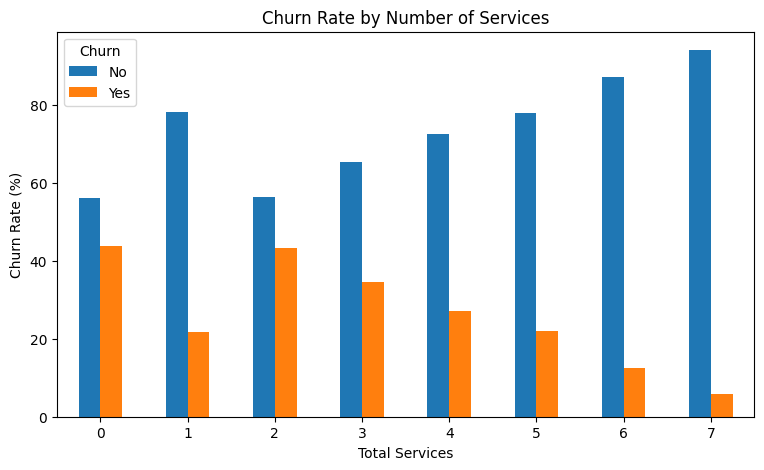

In [ ]:
# Services vs churn
services_churn.plot(
    kind="bar",
    figsize=(9, 5)
)

plt.title("Churn Rate by Number of Services")
plt.xlabel("Total Services")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.legend(title="Churn")

plt.show()

In [ ]:
# High value vs churn
high_value_churn = pd.crosstab(
    df_clean["is_high_value_customer"],
    df_clean["Churn"],
    normalize="index"
) * 100

print(high_value_churn)

Churn                          No        Yes
is_high_value_customer                      
0                       75.521426  24.478574
1                       67.121729  32.878271


In [ ]:
#Month-to-month vs churn
monthly_contract_churn = pd.crosstab(
    df_clean["is_month_to_month"],
    df_clean["Churn"],
    normalize="index"
) * 100

print(monthly_contract_churn)

Churn                     No        Yes
is_month_to_month                      
0                  93.221413   6.778587
1                  57.290323  42.709677


In [ ]:
# Remove tenure group
df_clean = df_clean.drop(
    "tenure_group",
    axis=1
)

print("Shape:", df_clean.shape)

Shape: (7032, 25)


## 4. Feature Engineering and Target Preparation

The engineered variables capture service breadth, contract type, customer value, relationship status, and average monthly spend.

In [ ]:
# Convert target
df_clean["Churn"] = df_clean["Churn"].map({
    "No": 0,
    "Yes": 1
})

print(
    df_clean["Churn"].value_counts()
)

Churn
0    5163
1    1869
Name: count, dtype: int64


In [ ]:
# Separate X and Y
X = df_clean.drop(
    "Churn",
    axis=1
)

y = df_clean["Churn"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (7032, 24)
y shape: (7032,)


In [ ]:
#Identify feature types
numerical_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'total_services', 'is_high_value_customer', 'is_month_to_month', 'has_partner_or_dependents', 'avg_monthly_spend']

Categorical features:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [ ]:
# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (5625, 24)
Testing data: (1407, 24)


In [ ]:
# Check target distribution
print("Original:")
print(
    y.value_counts(normalize=True) * 100
)

print("\nTraining:")
print(
    y_train.value_counts(normalize=True) * 100
)

print("\nTesting:")
print(
    y_test.value_counts(normalize=True) * 100
)

Original:
Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64

Training:
Churn
0    73.422222
1    26.577778
Name: proportion, dtype: float64

Testing:
Churn
0    73.418621
1    26.581379
Name: proportion, dtype: float64


In [ ]:
# Build preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        )
    ]
)

X_train_processed = (
    preprocessor.fit_transform(X_train)
)

X_test_processed = (
    preprocessor.transform(X_test)
)

print(
    "Training processed shape:",
    X_train_processed.shape
)

print(
    "Testing processed shape:",
    X_test_processed.shape
)

Training processed shape: (5625, 35)
Testing processed shape: (1407, 35)


## 5. Baseline Model Development

Three classifiers are compared before tuning: Logistic Regression, Random Forest, and XGBoost.

In [ ]:
# Logistic Regression
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(
    X_train_processed,
    y_train
)

print(
    "Logistic Regression trained successfully!"
)

Logistic Regression trained successfully!


In [ ]:
# Logistic predictions
y_pred = logistic_model.predict(
    X_test_processed
)

y_probability = logistic_model.predict_proba(
    X_test_processed
)[:, 1]

In [ ]:
# Logistic evaluation
accuracy = accuracy_score(
    y_test,
    y_pred
)

precision = precision_score(
    y_test,
    y_pred
)

recall = recall_score(
    y_test,
    y_pred
)

f1 = f1_score(
    y_test,
    y_pred
)

roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print("Logistic Regression Results")
print("----------------------------")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}")

Logistic Regression Results
----------------------------
Accuracy : 0.8031
Precision: 0.6483
Recall   : 0.5668
F1 Score : 0.6049
ROC-AUC  : 0.8358


In [ ]:
# Logistic lasssification report
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.60       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



[[918 115]
 [162 212]]


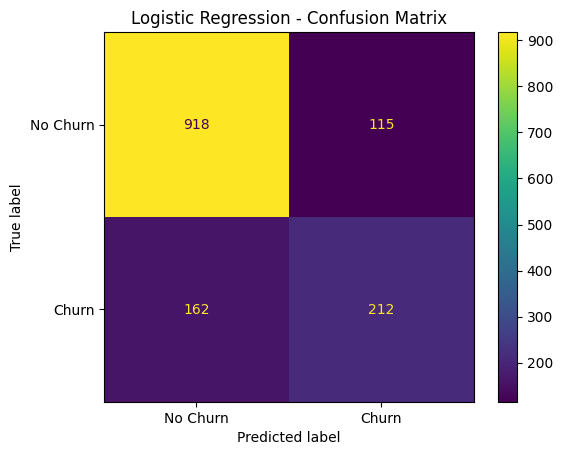

In [ ]:
# Logistic confusion matrix
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "No Churn",
        "Churn"
    ]
).plot()

plt.title(
    "Logistic Regression - Confusion Matrix"
)

plt.show()

In [ ]:
# Random forest
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=8,
    min_samples_split=10,
    min_samples_leaf=4,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(
    X_train_processed,
    y_train
)

print(
    "Random Forest trained successfully!"
)

Random Forest trained successfully!


In [ ]:
# Random forest prediction
rf_pred = rf_model.predict(
    X_test_processed
)

rf_probability = rf_model.predict_proba(
    X_test_processed
)[:, 1]

In [ ]:
# Random forest evaluation
rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

rf_precision = precision_score(
    y_test,
    rf_pred
)

rf_recall = recall_score(
    y_test,
    rf_pred
)

rf_f1 = f1_score(
    y_test,
    rf_pred
)

rf_roc_auc = roc_auc_score(
    y_test,
    rf_probability
)

print("Random Forest Results")
print("---------------------")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")
print(f"ROC-AUC  : {rf_roc_auc:.4f}")

Random Forest Results
---------------------
Accuracy : 0.7434
Precision: 0.5113
Recall   : 0.7861
F1 Score : 0.6196
ROC-AUC  : 0.8362


In [ ]:
# XGBoost
xgb_model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_processed,
    y_train
)

print(
    "XGBoost trained successfully!"
)

XGBoost trained successfully!


In [ ]:
# XGBoost predictions
xgb_pred = xgb_model.predict(
    X_test_processed
)

xgb_probability = xgb_model.predict_proba(
    X_test_processed
)[:, 1]

In [ ]:
# XGBoost evaluation
xgb_accuracy = accuracy_score(
    y_test,
    xgb_pred
)

xgb_precision = precision_score(
    y_test,
    xgb_pred
)

xgb_recall = recall_score(
    y_test,
    xgb_pred
)

xgb_f1 = f1_score(
    y_test,
    xgb_pred
)

xgb_roc_auc = roc_auc_score(
    y_test,
    xgb_probability
)

print("XGBoost Results")
print("----------------")
print(f"Accuracy : {xgb_accuracy:.4f}")
print(f"Precision: {xgb_precision:.4f}")
print(f"Recall   : {xgb_recall:.4f}")
print(f"F1 Score : {xgb_f1:.4f}")
print(f"ROC-AUC  : {xgb_roc_auc:.4f}")

XGBoost Results
----------------
Accuracy : 0.7839
Precision: 0.6115
Recall   : 0.5134
F1 Score : 0.5581
ROC-AUC  : 0.8292


In [ ]:
# FIrst model comparisom
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy,
        xgb_accuracy
    ],
    "Precision": [
        precision,
        rf_precision,
        xgb_precision
    ],
    "Recall": [
        recall,
        rf_recall,
        xgb_recall
    ],
    "F1 Score": [
        f1,
        rf_f1,
        xgb_f1
    ],
    "ROC-AUC": [
        roc_auc,
        rf_roc_auc,
        xgb_roc_auc
    ]
})

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8031,0.6483,0.5668,0.6049,0.8358
1,Random Forest,0.7434,0.5113,0.7861,0.6196,0.8362
2,XGBoost,0.7839,0.6115,0.5134,0.5581,0.8292


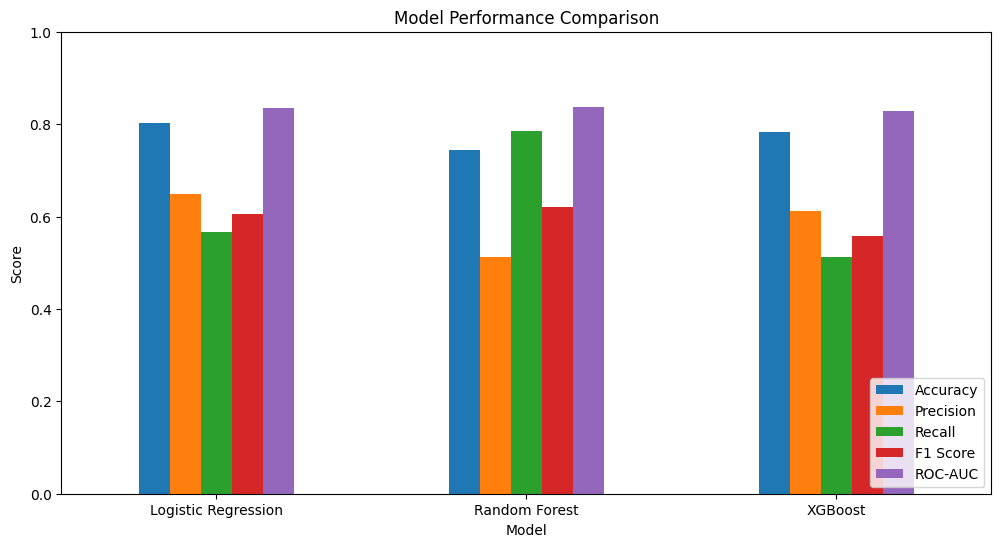

In [ ]:
# Model comparison visualization
metrics = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1 Score",
    "ROC-AUC"
]

model_comparison.set_index(
    "Model"
)[metrics].plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title(
    "Model Performance Comparison"
)

plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")

plt.show()

In [ ]:
# Create a validation set for hyperparameter tuning and threshold selection
# The test set remains untouched until final evaluation.
X_train_new, X_valid, y_train_new, y_valid = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Training subset:", X_train_new.shape)
print("Validation set:", X_valid.shape)

Training subset: (4500, 24)
Validation set: (1125, 24)


In [ ]:
# Preprocessing for tuning
preprocessor_tuning = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        )
    ]
)

X_train_new_processed = (
    preprocessor_tuning.fit_transform(
        X_train_new
    )
)

X_valid_processed = (
    preprocessor_tuning.transform(
        X_valid
    )
)

print(
    "Training processed:",
    X_train_new_processed.shape
)

print(
    "Validation processed:",
    X_valid_processed.shape
)

Training processed: (4500, 35)
Validation processed: (1125, 35)


In [ ]:
# Hyperparameter tuning
param_grid = {
    "n_estimators": [200, 300],
    "max_depth": [3, 4, 5],
    "learning_rate": [0.03, 0.05, 0.1],
    "subsample": [0.8, 1.0]
}

xgb_tune = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

grid = GridSearchCV(
    estimator=xgb_tune,
    param_grid=param_grid,
    scoring="roc_auc",
    cv=3,
    n_jobs=-1,
    refit=True
)

grid.fit(X_train_new_processed, y_train_new)

print("Best parameters:", grid.best_params_)
print("Best CV ROC-AUC:", round(grid.best_score_, 4))

Best parameters: {'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}
Best CV ROC-AUC: 0.8512


In [ ]:
# Validation performance
best_xgb = grid.best_estimator_

valid_prob = best_xgb.predict_proba(X_valid_processed)[:, 1]
valid_pred_05 = (valid_prob >= 0.5).astype(int)

print("Validation ROC-AUC:", round(roc_auc_score(y_valid, valid_prob), 4))
print(classification_report(y_valid, valid_pred_05, target_names=["No Churn", "Churn"]))

Validation ROC-AUC: 0.8379
              precision    recall  f1-score   support

    No Churn       0.83      0.90      0.86       826
       Churn       0.65      0.48      0.55       299

    accuracy                           0.79      1125
   macro avg       0.74      0.69      0.71      1125
weighted avg       0.78      0.79      0.78      1125



In [ ]:
# Select the operating threshold using validation data only
precision_vals, recall_vals, thresholds = precision_recall_curve(y_valid, valid_prob)

f1_vals = (
    2 * precision_vals[:-1] * recall_vals[:-1]
    / (precision_vals[:-1] + recall_vals[:-1] + 1e-9)
)

best_idx = np.argmax(f1_vals)
best_threshold = float(thresholds[best_idx])
best_validation_f1 = float(f1_vals[best_idx])

print("Best threshold:", round(best_threshold, 3))
print("Best validation F1:", round(best_validation_f1, 4))

Best threshold: 0.349
Best validation F1: 0.6289


In [ ]:
# Fit the final preprocessing transformer on the complete training set
# The test set is transformed only after the transformer has been fitted.
final_preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                drop="first"
            ),
            categorical_features
        )
    ]
)

X_train_final = final_preprocessor.fit_transform(X_train)
X_test_final = final_preprocessor.transform(X_test)

print("Final training shape:", X_train_final.shape)
print("Final testing shape:", X_test_final.shape)

Final training shape: (5625, 35)
Final testing shape: (1407, 35)


In [ ]:
# Final XGBoost
# IMPORTANT: use the hyperparameters selected by GridSearchCV rather than
# manually entering a different set of values.
final_params = grid.best_params_.copy()

final_xgb = XGBClassifier(
    **final_params,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

final_xgb.fit(X_train_final, y_train)

print("Final XGBoost trained successfully!")
print("Final parameters:", final_params)

Final XGBoost trained successfully!
Final parameters: {'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}


In [ ]:
# Final XGBoost
# IMPORTANT: use the hyperparameters selected by GridSearchCV rather than
# manually entering a different set of values.
final_params = grid.best_params_.copy()

final_xgb = XGBClassifier(
    **final_params,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    n_jobs=-1
)

final_xgb.fit(X_train_final, y_train)

print("Final XGBoost trained successfully!")
print("Final parameters:", final_params)

Final XGBoost trained successfully!
Final parameters: {'learning_rate': 0.03, 'max_depth': 3, 'n_estimators': 200, 'subsample': 0.8}


In [ ]:
# Final prediction using the validation-selected threshold
test_prob = final_xgb.predict_proba(X_test_final)[:, 1]
test_pred = (test_prob >= best_threshold).astype(int)

print("Predictions generated successfully!")

Predictions generated successfully!


In [ ]:
# final  model evaluation
final_accuracy = accuracy_score(
    y_test,
    test_pred
)

final_precision = precision_score(
    y_test,
    test_pred
)

final_recall = recall_score(
    y_test,
    test_pred
)

final_f1 = f1_score(
    y_test,
    test_pred
)

final_roc_auc = roc_auc_score(
    y_test,
    test_prob
)

print("FINAL MODEL")
print("-----------")
print(
    f"Accuracy : {final_accuracy:.4f}"
)
print(
    f"Precision: {final_precision:.4f}"
)
print(
    f"Recall   : {final_recall:.4f}"
)
print(
    f"F1 Score : {final_f1:.4f}"
)
print(
    f"ROC-AUC  : {final_roc_auc:.4f}"
)

FINAL MODEL
-----------
Accuracy : 0.7761
Precision: 0.5589
Recall   : 0.7487
F1 Score : 0.6400
ROC-AUC  : 0.8402


In [ ]:
# Final classificaton report


print(
    classification_report(
        y_test,
        test_pred,
        target_names=[
            "No Churn",
            "Churn"
        ]
    )
)

              precision    recall  f1-score   support

    No Churn       0.90      0.79      0.84      1033
       Churn       0.56      0.75      0.64       374

    accuracy                           0.78      1407
   macro avg       0.73      0.77      0.74      1407
weighted avg       0.81      0.78      0.79      1407



[[812 221]
 [ 94 280]]


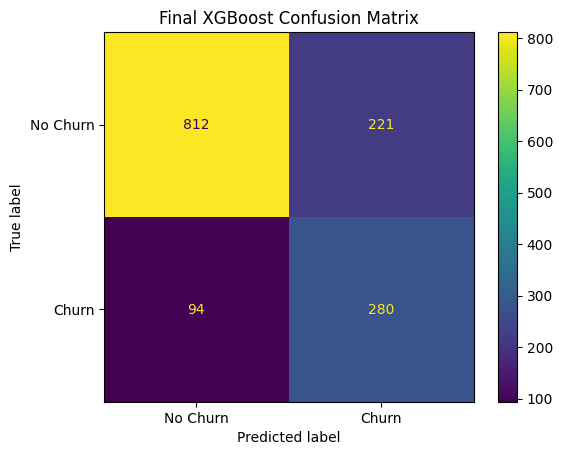

In [ ]:
# Final confusion matrix
final_cm = confusion_matrix(
    y_test,
    test_pred
)

print(final_cm)

ConfusionMatrixDisplay(
    confusion_matrix=final_cm,
    display_labels=[
        "No Churn",
        "Churn"
    ]
).plot()

plt.title(
    "Final XGBoost Confusion Matrix"
)

plt.show()

In [ ]:
# Final model comparison
final_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Tuned XGBoost"
    ],
    "Accuracy": [accuracy, rf_accuracy, xgb_accuracy, final_accuracy],
    "Precision": [precision, rf_precision, xgb_precision, final_precision],
    "Recall": [recall, rf_recall, xgb_recall, final_recall],
    "F1 Score": [f1, rf_f1, xgb_f1, final_f1],
    "ROC-AUC": [roc_auc, rf_roc_auc, xgb_roc_auc, final_roc_auc]
})

final_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8031,0.6483,0.5668,0.6049,0.8358
1,Random Forest,0.7434,0.5113,0.7861,0.6196,0.8362
2,XGBoost,0.7839,0.6115,0.5134,0.5581,0.8292
3,Tuned XGBoost,0.7761,0.5589,0.7487,0.6400,0.8402


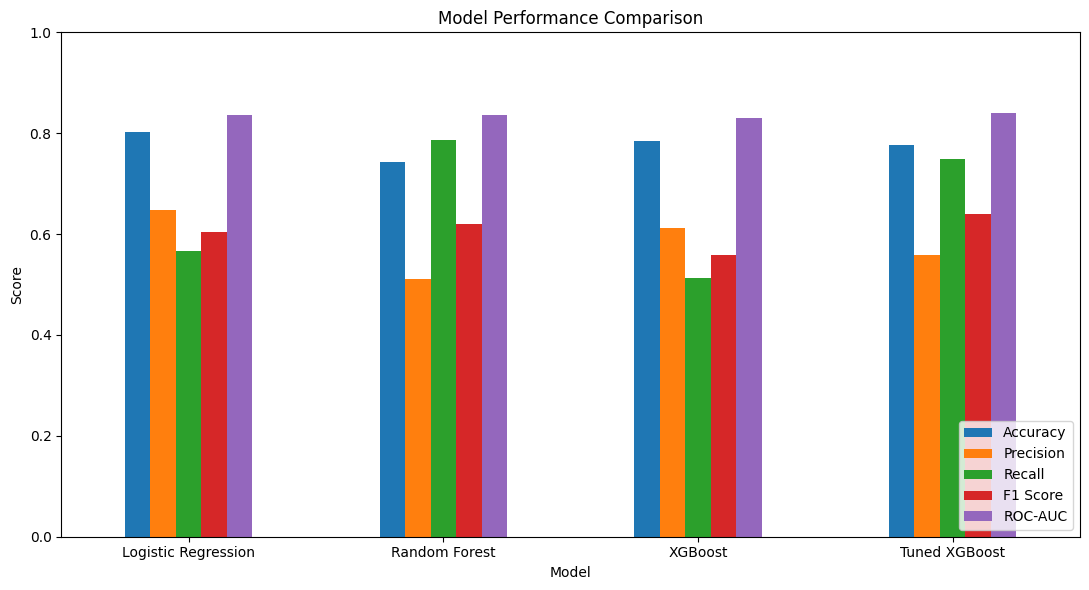

In [ ]:
# Compare model performance visually
plot_df = final_comparison.set_index("Model")[[
    "Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"
]]

ax = plot_df.plot(kind="bar", figsize=(11, 6))
ax.set_title("Model Performance Comparison")
ax.set_xlabel("Model")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

## 7. Explainability with SHAP

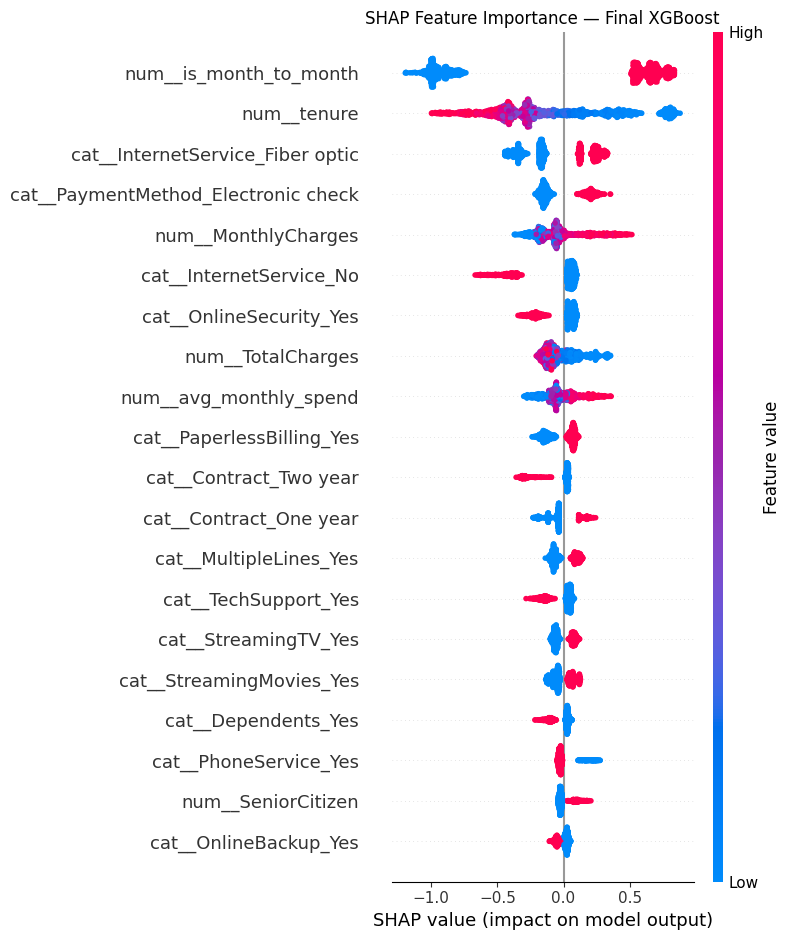

In [ ]:
# SHAP explainability
feature_names = final_preprocessor.get_feature_names_out()
explainer = shap.TreeExplainer(final_xgb)
shap_values = explainer.shap_values(X_test_final)

shap.summary_plot(
    shap_values,
    X_test_final,
    feature_names=feature_names,
    show=False
)
plt.title("SHAP Feature Importance — Final XGBoost")
plt.tight_layout()
plt.show()

In [ ]:
# Save the final model, preprocessor, and decision threshold
joblib.dump(final_xgb, "customer_churn_xgboost.pkl")
joblib.dump(final_preprocessor, "churn_preprocessor.pkl")
joblib.dump(best_threshold, "churn_threshold.pkl")
joblib.dump(high_value_threshold, "high_value_threshold.pkl")

print("Model, preprocessor, threshold, and feature threshold saved successfully!")

Model, preprocessor, threshold, and feature threshold saved successfully!


In [ ]:
# Save the final model, preprocessor, and decision threshold
joblib.dump(final_xgb, "customer_churn_xgboost.pkl")
joblib.dump(final_preprocessor, "churn_preprocessor.pkl")
joblib.dump(best_threshold, "churn_threshold.pkl")
joblib.dump(high_value_threshold, "high_value_threshold.pkl")

print("Model, preprocessor, threshold, and feature threshold saved successfully!")

Model, preprocessor, threshold, and feature threshold saved successfully!


In [ ]:
# Business insights and recommended actions
print("""
KEY BUSINESS INSIGHTS
---------------------

1. Month-to-month customers show substantially higher churn risk.
2. Customers with shorter tenure are more likely to churn.
3. Electronic-check customers show higher churn in this dataset.
4. Fiber-optic customers show higher churn than DSL customers in this dataset.
5. Higher monthly charges are associated with greater churn risk.
6. Customers with fewer subscribed services generally show higher churn risk.

BUSINESS RECOMMENDATIONS
------------------------

1. Encourage month-to-month customers to move to longer-term contracts.
2. Launch early-retention campaigns for newly acquired customers.
3. Investigate pricing and service-quality concerns among high-charge customers.
4. Encourage automatic payment methods.
5. Prioritize high-risk customers identified by the model for retention outreach.
6. Use SHAP explanations to support customer-level retention decisions.

NOTE: These are dataset-level associations, not causal conclusions.
""")


KEY BUSINESS INSIGHTS
---------------------

1. Month-to-month customers show substantially higher churn risk.
2. Customers with shorter tenure are more likely to churn.
3. Electronic-check customers show higher churn in this dataset.
4. Fiber-optic customers show higher churn than DSL customers in this dataset.
5. Higher monthly charges are associated with greater churn risk.
6. Customers with fewer subscribed services generally show higher churn risk.

BUSINESS RECOMMENDATIONS
------------------------

1. Encourage month-to-month customers to move to longer-term contracts.
2. Launch early-retention campaigns for newly acquired customers.
3. Investigate pricing and service-quality concerns among high-charge customers.
4. Encourage automatic payment methods.
5. Prioritize high-risk customers identified by the model for retention outreach.
6. Use SHAP explanations to support customer-level retention decisions.

NOTE: These are dataset-level associations, not causal conclusions.



## 8. Model Export and Deployment

The trained artifacts are serialized for reuse by the Streamlit app. The notebook also generates the deployment files (`app.py`, `requirements.txt`, and `README.md`).

In [ ]:
# Create Streamlit app
%%writefile app.py

import streamlit as st
import pandas as pd
import joblib

model = joblib.load("customer_churn_xgboost.pkl")
preprocessor = joblib.load("churn_preprocessor.pkl")
best_threshold = joblib.load("churn_threshold.pkl")
high_value_threshold = joblib.load("high_value_threshold.pkl")

st.set_page_config(
    page_title="Customer Churn Prediction",
    page_icon="📊",
    layout="wide"
)

st.title("📊 Customer Churn Prediction")
st.caption("Machine-learning powered customer churn risk prediction")
st.divider()
st.subheader("Customer Information")

col1, col2, col3 = st.columns(3)

with col1:
    gender = st.selectbox("Gender", ["Male", "Female"])
    senior = st.selectbox("Senior Citizen", [0, 1])
    partner = st.selectbox("Partner", ["Yes", "No"])
    dependents = st.selectbox("Dependents", ["Yes", "No"])
    tenure = st.slider("Tenure (Months)", 0, 72, 12)
    phone = st.selectbox("Phone Service", ["Yes", "No"])

with col2:
    multiple_lines = st.selectbox("Multiple Lines", ["Yes", "No", "No phone service"])
    internet = st.selectbox("Internet Service", ["DSL", "Fiber optic", "No"])
    security = st.selectbox("Online Security", ["Yes", "No", "No internet service"])
    backup = st.selectbox("Online Backup", ["Yes", "No", "No internet service"])
    device = st.selectbox("Device Protection", ["Yes", "No", "No internet service"])
    support = st.selectbox("Tech Support", ["Yes", "No", "No internet service"])

with col3:
    tv = st.selectbox("Streaming TV", ["Yes", "No", "No internet service"])
    movies = st.selectbox("Streaming Movies", ["Yes", "No", "No internet service"])
    contract = st.selectbox("Contract", ["Month-to-month", "One year", "Two year"])
    paperless = st.selectbox("Paperless Billing", ["Yes", "No"])
    payment = st.selectbox("Payment Method", [
        "Electronic check", "Mailed check",
        "Bank transfer (automatic)", "Credit card (automatic)"
    ])
    monthly_charges = st.number_input("Monthly Charges", min_value=0.0, value=70.0)
    total_charges = st.number_input("Total Charges", min_value=0.0, value=1000.0)

st.divider()

if st.button("🔮 Predict Churn", use_container_width=True):
    total_services = sum([
        phone == "Yes", security == "Yes", backup == "Yes",
        device == "Yes", support == "Yes", tv == "Yes", movies == "Yes"
    ])

    is_high_value = int(monthly_charges >= high_value_threshold)
    is_month_to_month = int(contract == "Month-to-month")
    has_partner_or_dependents = int(partner == "Yes" or dependents == "Yes")
    avg_monthly_spend = total_charges / tenure if tenure > 0 else monthly_charges

    input_data = pd.DataFrame({
        "gender": [gender], "SeniorCitizen": [senior], "Partner": [partner],
        "Dependents": [dependents], "tenure": [tenure], "PhoneService": [phone],
        "MultipleLines": [multiple_lines], "InternetService": [internet],
        "OnlineSecurity": [security], "OnlineBackup": [backup],
        "DeviceProtection": [device], "TechSupport": [support],
        "StreamingTV": [tv], "StreamingMovies": [movies], "Contract": [contract],
        "PaperlessBilling": [paperless], "PaymentMethod": [payment],
        "MonthlyCharges": [monthly_charges], "TotalCharges": [total_charges],
        "total_services": [total_services],
        "is_high_value_customer": [is_high_value],
        "is_month_to_month": [is_month_to_month],
        "has_partner_or_dependents": [has_partner_or_dependents],
        "avg_monthly_spend": [avg_monthly_spend]
    })

    processed = preprocessor.transform(input_data)
    probability = float(model.predict_proba(processed)[0, 1])
    prediction = probability >= best_threshold

    st.subheader("Prediction Result")
    st.metric("Churn Probability", f"{probability:.1%}")
    st.caption(f"Decision threshold: {best_threshold:.3f}")

    if prediction:
        st.error(" HIGH CHURN RISK")
        st.warning("Recommended action: Contact the customer with a targeted retention offer.")
    else:
        st.success(" LOW CHURN RISK")
        st.info("Recommended action: Continue regular customer engagement.")


Overwriting app.py


In [ ]:
# Create requirements.txt
%%writefile requirements.txt
streamlit
pandas
numpy
scikit-learn
xgboost
joblib
shap
matplotlib


Writing requirements.txt


In [ ]:
# Create README.md
readme = f"""# Customer Churn Prediction

An end-to-end machine learning project that predicts telecom customer churn and converts model predictions into actionable retention insights.

## Business Problem

Customer churn directly affects recurring revenue. The goal is to identify customers with a higher probability of churn early enough for targeted retention action.

## Project Workflow

1. Data loading and quality checks
2. Exploratory data analysis
3. Feature engineering
4. Train/test split with stratification
5. Preprocessing with `ColumnTransformer`
6. Baseline model comparison
7. XGBoost hyperparameter tuning with cross-validation
8. Validation-based probability-threshold selection
9. Final test evaluation
10. SHAP explainability
11. Model serialization
12. Streamlit deployment

## Models Evaluated

- Logistic Regression
- Random Forest
- XGBoost
- Tuned XGBoost

## Model Selection

Hyperparameters are selected using `GridSearchCV` with ROC-AUC as the cross-validation scoring metric. The final XGBoost model uses the parameters returned by `grid.best_params_`; no separate manually entered parameter set is used.

The churn decision threshold is selected using the validation set to optimize F1 score. The test set is kept untouched until final evaluation.

## Final Results

| Metric | Score |
|---|---:|
| Accuracy | {final_accuracy:.2%} |
| Precision | {final_precision:.2%} |
| Recall | {final_recall:.2%} |
| F1 Score | {final_f1:.2%} |
| ROC-AUC | {final_roc_auc:.2%} |

**Validation-selected threshold:** {best_threshold:.3f}

**Best tuned parameters:** `{grid.best_params_}`

## Key Business Insights

- Month-to-month customers have substantially higher churn risk.
- Shorter-tenure customers are more likely to churn.
- Electronic-check customers show higher churn in this dataset.
- Fiber-optic customers show higher churn than DSL customers in this dataset.
- Higher monthly charges are associated with greater churn risk.

These findings describe associations in the dataset and should not be interpreted as causal effects without further analysis.

## Business Recommendations

- Encourage month-to-month customers to move to longer-term contracts.
- Launch early-retention campaigns for newly acquired customers.
- Investigate pricing and service-quality concerns among high-charge customers.
- Encourage automatic payment methods.
- Prioritize high-risk customers for targeted retention outreach.

## Explainability

SHAP is used to identify which features contribute most to individual and overall churn predictions, improving model transparency for business stakeholders.

## Deployment

A Streamlit application is included for interactive churn-risk prediction. The app loads the trained model, preprocessing transformer, learned decision threshold, and high-value customer threshold from serialized files.

### Run locally

```bash
pip install -r requirements.txt
streamlit run app.py
```

## Project Structure

```text
customer-churn-prediction/
├── app.py
├── requirements.txt
├── customer_churn_xgboost.pkl
├── churn_preprocessor.pkl
├── churn_threshold.pkl
├── high_value_threshold.pkl
├── model_comparison.csv
├── Telco-Customer-Churn.csv
├── Customer_Churn_Prediction_Recruiter_Ready.ipynb
└── README.md
```

## Technologies

Python · Pandas · NumPy · Scikit-learn · XGBoost · SHAP · Matplotlib · Streamlit
"""

with open("README.md", "w", encoding="utf-8") as f:
    f.write(readme)

print("README.md created successfully!")

README.md created successfully!


In [ ]:
# Check all files
import os

files = [
    "app.py",
    "requirements.txt",
    "README.md",
    "customer_churn_xgboost.pkl",
    "churn_preprocessor.pkl",
    "model_comparison.csv",
    "Telco-Customer-Churn.csv"
]

print("PROJECT FILE CHECK")
print("------------------")

for file in files:

    if os.path.exists(file):
        print(f"yes {file}")
    else:
        print(f"no {file}")

PROJECT FILE CHECK
------------------
yes app.py
yes requirements.txt
yes README.md
yes customer_churn_xgboost.pkl
yes churn_preprocessor.pkl
no model_comparison.csv
yes Telco-Customer-Churn.csv
